# Hydroclimate Analysis — Nevados de Chillán (Revised)
**Station data:** Las Trancas and Diguillín (CR2 / explorador.cr2.cl)

**Methods revision:** E-Divisive changepoint algorithm replaced with **segmented (piecewise linear) regression** following Reviewer 2 (Taylor) comments:
- E-Divisive assumes sudden distributional shifts (regime changes), inappropriate for gradual climate trends subject to ENSO variability
- Segmented regression identifies when the *rate of change accelerated*, gives the breakpoint year with 95% CI and pre/post slopes directly
- Sen's slope + Mann-Kendall retained unchanged (appropriate for monotonic trend detection)

**Reference:** Pilgrim (2021), *piecewise-regression* Python package.

## Imports

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'piecewise-regression'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'piecewise-regression'], returncode=0, stdout=b'Requirement already satisfied: piecewise-regression in /Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages (1.5.0)\nRequirement already satisfied: numpy in /Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages (from piecewise-regression) (1.26.4)\nRequirement already satisfied: matplotlib in /Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages (from piecewise-regression) (3.10.1)\nRequirement already satisfied: scipy in /Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages (from piecewise-regression) (1.15.2)\nRequirement already satisfied: statsmodels in /Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages (from piecewise-regression) (0.14.4)\nRequirement already satisfied: contourpy>=1.0.1 in /Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages (from

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pymannkendall as mk
import piecewise_regression

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       150,
})


## File paths  (update DATA_DIR if needed)

In [3]:
DATA_DIR    = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data'
FIGURES_DIR = '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

PRECIP_FILES = {
    'Diguillín':  os.path.join(DATA_DIR, 'pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv'),
    'Las Trancas':os.path.join(DATA_DIR, 'pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv'),
}
TEMP_FILES = {
    'tmax': os.path.join(DATA_DIR, 'temp_max_diguillin.csv'),
    'tmin': os.path.join(DATA_DIR, 'temp_min_diguillin.csv'),
}
STREAMFLOW_FILE = os.path.join(DATA_DIR, 'streamflow_diguillin.csv')


## Data loaders

In [4]:
def load_precip_monthly(filepath):
    """Load monthly precip CSV (Fecha, Estacion_mm, ...). Returns daily-indexed df."""
    df = pd.read_csv(filepath, encoding='latin-1')
    df.replace(-9999, np.nan, inplace=True)
    df['date']   = pd.to_datetime(df.iloc[:, 0], format='%Y-%m', errors='coerce')
    df['precip'] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
    df['year']   = df['date'].dt.year
    df['month']  = df['date'].dt.month
    df['summer_year'] = df['year'].copy()
    df.loc[df['month'] == 12, 'summer_year'] = df.loc[df['month'] == 12, 'year'] + 1
    return df.dropna(subset=['precip', 'date']).reset_index(drop=True)


def load_temp_daily(filepath):
    """Load daily temp CSV (agno, mes, dia, valor). Returns df with date, valor, month, year."""
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    df['date']  = pd.to_datetime(
        df[['agno', 'mes', 'dia']].astype(str).agg('-'.join, axis=1), errors='coerce')
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce').replace(-9999, np.nan)
    df = df.dropna(subset=['valor', 'date']).copy()
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['summer_year'] = df['year'].copy()
    df.loc[df['month'] == 12, 'summer_year'] = df.loc[df['month'] == 12, 'year'] + 1
    return df.reset_index(drop=True)


def load_streamflow_daily(filepath):
    """Load daily streamflow CSV (agno, mes, dia, valor)."""
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    df['date']  = pd.to_datetime(
        df[['agno', 'mes', 'dia']].astype(str).agg('-'.join, axis=1), errors='coerce')
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce').replace(-9999, np.nan)
    df = df.dropna(subset=['valor', 'date']).copy()
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['summer_year'] = df['year'].copy()
    df.loc[df['month'] == 12, 'summer_year'] = df.loc[df['month'] == 12, 'year'] + 1
    return df.reset_index(drop=True)


## Aggregation helpers

In [5]:
def annual_precip(df):
    return df.groupby('year')['precip'].sum(min_count=6).rename('value')


def annual_temp(df, col='valor', agg='mean'):
    fn = {'mean': 'mean', 'min': 'min', 'max': 'max'}[agg]
    return df.groupby('year')[col].agg(fn).rename('value')


def annual_streamflow(df):
    return df.groupby('year')['valor'].sum(min_count=300).rename('value')


def monthly_agg(df, month, value_col, agg='mean'):
    sub = df[df['month'] == month].groupby('summer_year')[value_col]
    if agg == 'mean':
        return sub.mean().rename('value')
    elif agg == 'sum':
        return sub.sum(min_count=1).rename('value')  # was 20 — only valid for daily data


## Statistical analysis functions

In [6]:
def sens_mk(series):
    """Sen's slope + Mann-Kendall. Returns (slope, p, significant)."""
    clean = series.dropna()
    if len(clean) < 10:
        return np.nan, np.nan, False
    res = mk.original_test(clean.values)
    return res.slope, res.p, res.p < 0.05


def fit_trend_line(years, values, slope):
    """Sen's slope trend line through median point."""
    years  = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    intercept = np.nanmedian(values) - slope * np.nanmedian(years)
    return years, slope * years + intercept


def fit_segmented_regression(years, values):
    """
    Fit piecewise linear regression with one breakpoint.
    Non-convergence indicates no statistically robust single breakpoint exists —
    the trend is better characterised as monotonic rather than a step change.
    This is reported as a result, not a failure (see response to Reviewer 2, Taylor).
    """
    
    mask = np.isfinite(np.asarray(values, dtype=float))
    x = np.asarray(years,  dtype=float)[mask]
    y = np.asarray(values, dtype=float)[mask]

    if len(x) < 15:
        return None
    try:
        pw = piecewise_regression.Fit(x, y, n_breakpoints=1,
                               start_values=[np.median(x)],
                               verbose=False)
        if not pw.converged:
            return None
        res    = pw.get_results()
        bp     = res['breakpoints'][0]
        bp_ci  = res['breakpoints_confidence_intervals'][0]
        params = res['estimates']
        alpha1 = params.get('alpha1', {}).get('estimate', np.nan)
        alpha2 = params.get('alpha2', {}).get('estimate', np.nan)
        return {
            'breakpoint':   bp,
            'bp_ci_lower':  bp_ci[0],
            'bp_ci_upper':  bp_ci[1],
            'slope_before': alpha1,
            'slope_after':  alpha1 + alpha2,   # segmented: after = before + delta
            'fit':          pw,
        }
    except Exception:
        return None


## Core panel plotting function (preserves R plot style)

In [7]:
def plot_panel(ax, series, label, ylabel, unit,
               panel_letter=None, split_year=2000,
               color_data='black', markersize=4):
    """
    Single trend panel replicating R base-graphics style:
      - black scatter + line
      - blue solid  = full Sen's slope trend (if p<0.05)
      - darkgreen -- = pre-split_year trend (if p<0.05)
      - purple --    = post-split_year trend (if p<0.05)
      - red --       = segmented regression breakpoint + CI shading
      - panel letter top-left
      - legend with slopes and p-values
    """
    series = series.dropna().sort_index()
    x      = series.index.values.astype(float)
    y      = series.values.astype(float)

    # Raw data
    ax.plot(x, y, 'o-', color=color_data, markersize=markersize,
            linewidth=0.9, alpha=0.75, zorder=2)

    legend_handles = []

    # ── Full trend ─────────────────────────────────────────────────────────
    slope_f, p_f, sig_f = sens_mk(series)
    if sig_f:
        xf, yf = fit_trend_line(x, y, slope_f)
        ax.plot(xf, yf, color='steelblue', linewidth=2.0, zorder=3)
        legend_handles.append(mlines.Line2D(
            [], [], color='steelblue', linewidth=2,
            label=f'Full: {slope_f:.3f} {unit}/yr  p={p_f:.3f}'))

    # ── Pre / post split_year trends ───────────────────────────────────────
    for sub_idx, col, lbl in [
        (x < split_year,  'darkgreen', f'Pre-{split_year}'),
        (x >= split_year, 'purple',    f'Post-{split_year}'),
    ]:
        if sub_idx.sum() > 5:
            x_s = x[sub_idx];  y_s = y[sub_idx]
            sl_s, p_s, sig_s = sens_mk(pd.Series(y_s, index=x_s.astype(int)))
            if sig_s:
                _, y_sf = fit_trend_line(x_s, y_s, sl_s)
                ax.plot(x_s, y_sf, color=col, linewidth=2.0,
                        linestyle='--', zorder=3)
                legend_handles.append(mlines.Line2D(
                    [], [], color=col, linewidth=2, linestyle='--',
                    label=f'{lbl}: {sl_s:.3f} {unit}/yr  p={p_s:.3f}'))

    # ── Segmented regression breakpoint ───────────────────────────────────
    seg = fit_segmented_regression(x, y)
    if seg is not None:
        bp, bpl, bph = seg['breakpoint'], seg['bp_ci_lower'], seg['bp_ci_upper']
        ax.axvline(bp,  color='red', linewidth=1.5, linestyle='--', zorder=4)
        ax.axvspan(bpl, bph, alpha=0.12, color='red', zorder=1)
        bp_int = int(round(bp))
        legend_handles.append(mlines.Line2D(
            [], [], color='red', linewidth=1.5, linestyle='--',
            label=f'Breakpoint: {bp_int} [{int(bpl)}–{int(bph)}]'))

    # ── Axes formatting ────────────────────────────────────────────────────
    ax.set_title(label,  fontsize=10, fontweight='bold', pad=5)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=8)

    if panel_letter:
        ax.text(0.02, 0.97, panel_letter, transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top')

    if legend_handles:
        ax.legend(handles=legend_handles, fontsize=7.5, loc='upper right',
                  framealpha=0.9, edgecolor='none', borderpad=0.4)

    return slope_f, p_f


## Fig 6: Annual trends (2 precip + 3 temp + 1 streamflow = 6 panels)

Generating Fig 6: Annual trends...


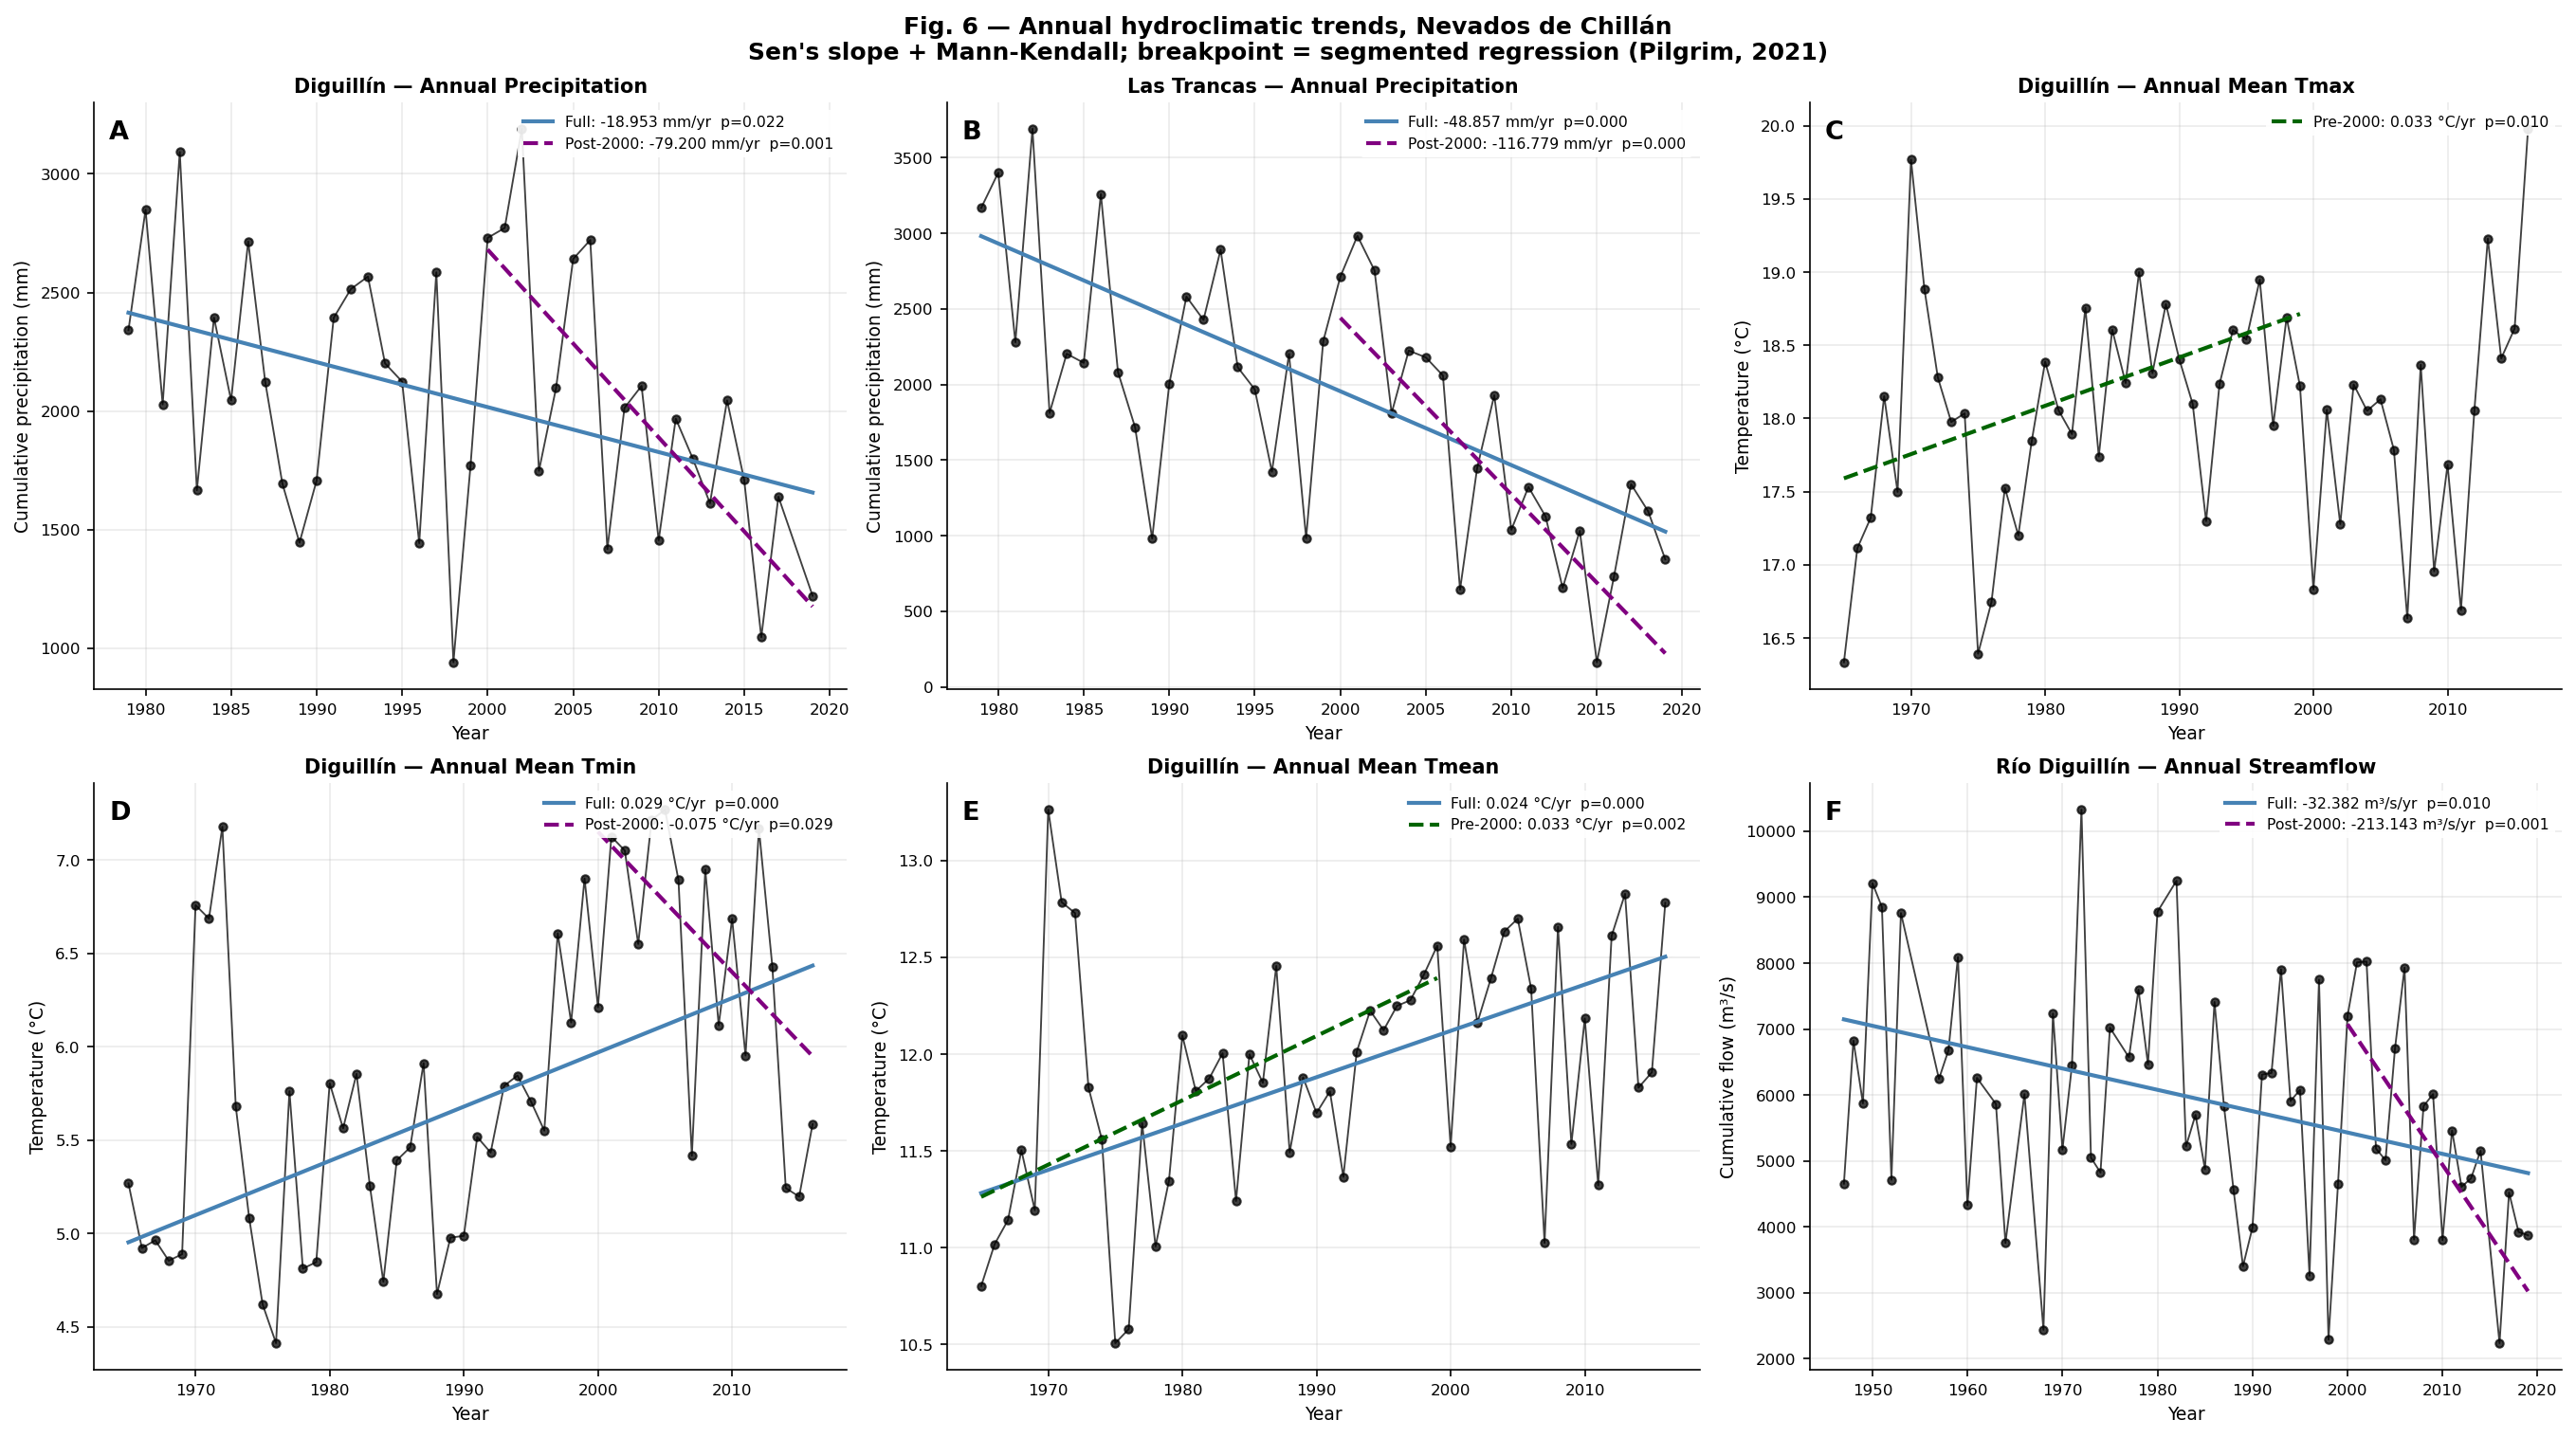

Saved: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures/fig6_annual_trends.png


In [8]:
print('Generating Fig 6: Annual trends...')

# Load data
tmax_df   = load_temp_daily(TEMP_FILES['tmax'])
tmin_df   = load_temp_daily(TEMP_FILES['tmin'])
stream_df = load_streamflow_daily(STREAMFLOW_FILE)

# Merge tmax/tmin for tmean
temp_merged = pd.merge(
    tmax_df[['date','year','valor']].rename(columns={'valor':'tmax'}),
    tmin_df[['date','year','valor']].rename(columns={'valor':'tmin'}),
    on=['date','year'])
temp_merged['tmean'] = (temp_merged['tmax'] + temp_merged['tmin']) / 2

ann_tmax   = temp_merged.groupby('year')['tmax'].mean().rename('value')
ann_tmin   = temp_merged.groupby('year')['tmin'].mean().rename('value')
ann_tmean  = temp_merged.groupby('year')['tmean'].mean().rename('value')
ann_stream = annual_streamflow(stream_df)

fig6, axes6 = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes6 = axes6.flatten()

panel_letters = ['A', 'B', 'C', 'D', 'E', 'F']

# Panels A-B: precipitation
for i, (station, fpath) in enumerate(PRECIP_FILES.items()):
    df_p  = load_precip_monthly(fpath)
    ann_p = annual_precip(df_p)
    plot_panel(axes6[i], ann_p,
               label=f'{station} — Annual Precipitation',
               ylabel='Cumulative precipitation (mm)',
               unit='mm', panel_letter=panel_letters[i])

# Panels C-E: temperature (Tmax, Tmin, Tmean)
for i, (series, lbl) in enumerate([(ann_tmax, 'Tmax'), (ann_tmin, 'Tmin'), (ann_tmean, 'Tmean')]):
    plot_panel(axes6[i+2], series,
               label=f'Diguillín — Annual Mean {lbl}',
               ylabel='Temperature (°C)',
               unit='°C', panel_letter=panel_letters[i+2])

# Panel F: streamflow
plot_panel(axes6[5], ann_stream,
           label='Río Diguillín — Annual Streamflow',
           ylabel='Cumulative flow (m³/s)',
           unit='m³/s', panel_letter='F')

fig6.suptitle(
    'Fig. 6 — Annual hydroclimatic trends, Nevados de Chillán\n'
    'Sen\'s slope + Mann-Kendall; breakpoint = segmented regression (Pilgrim, 2021)',
    fontsize=12, fontweight='bold')

fig6_path = os.path.join(FIGURES_DIR, 'fig6_annual_trends.png')
fig6.savefig(fig6_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig6_path}')


## Fig 7: Summer (DJF) temperature — 3×3 grid


Generating Fig 7: Summer temperature (DJF)...


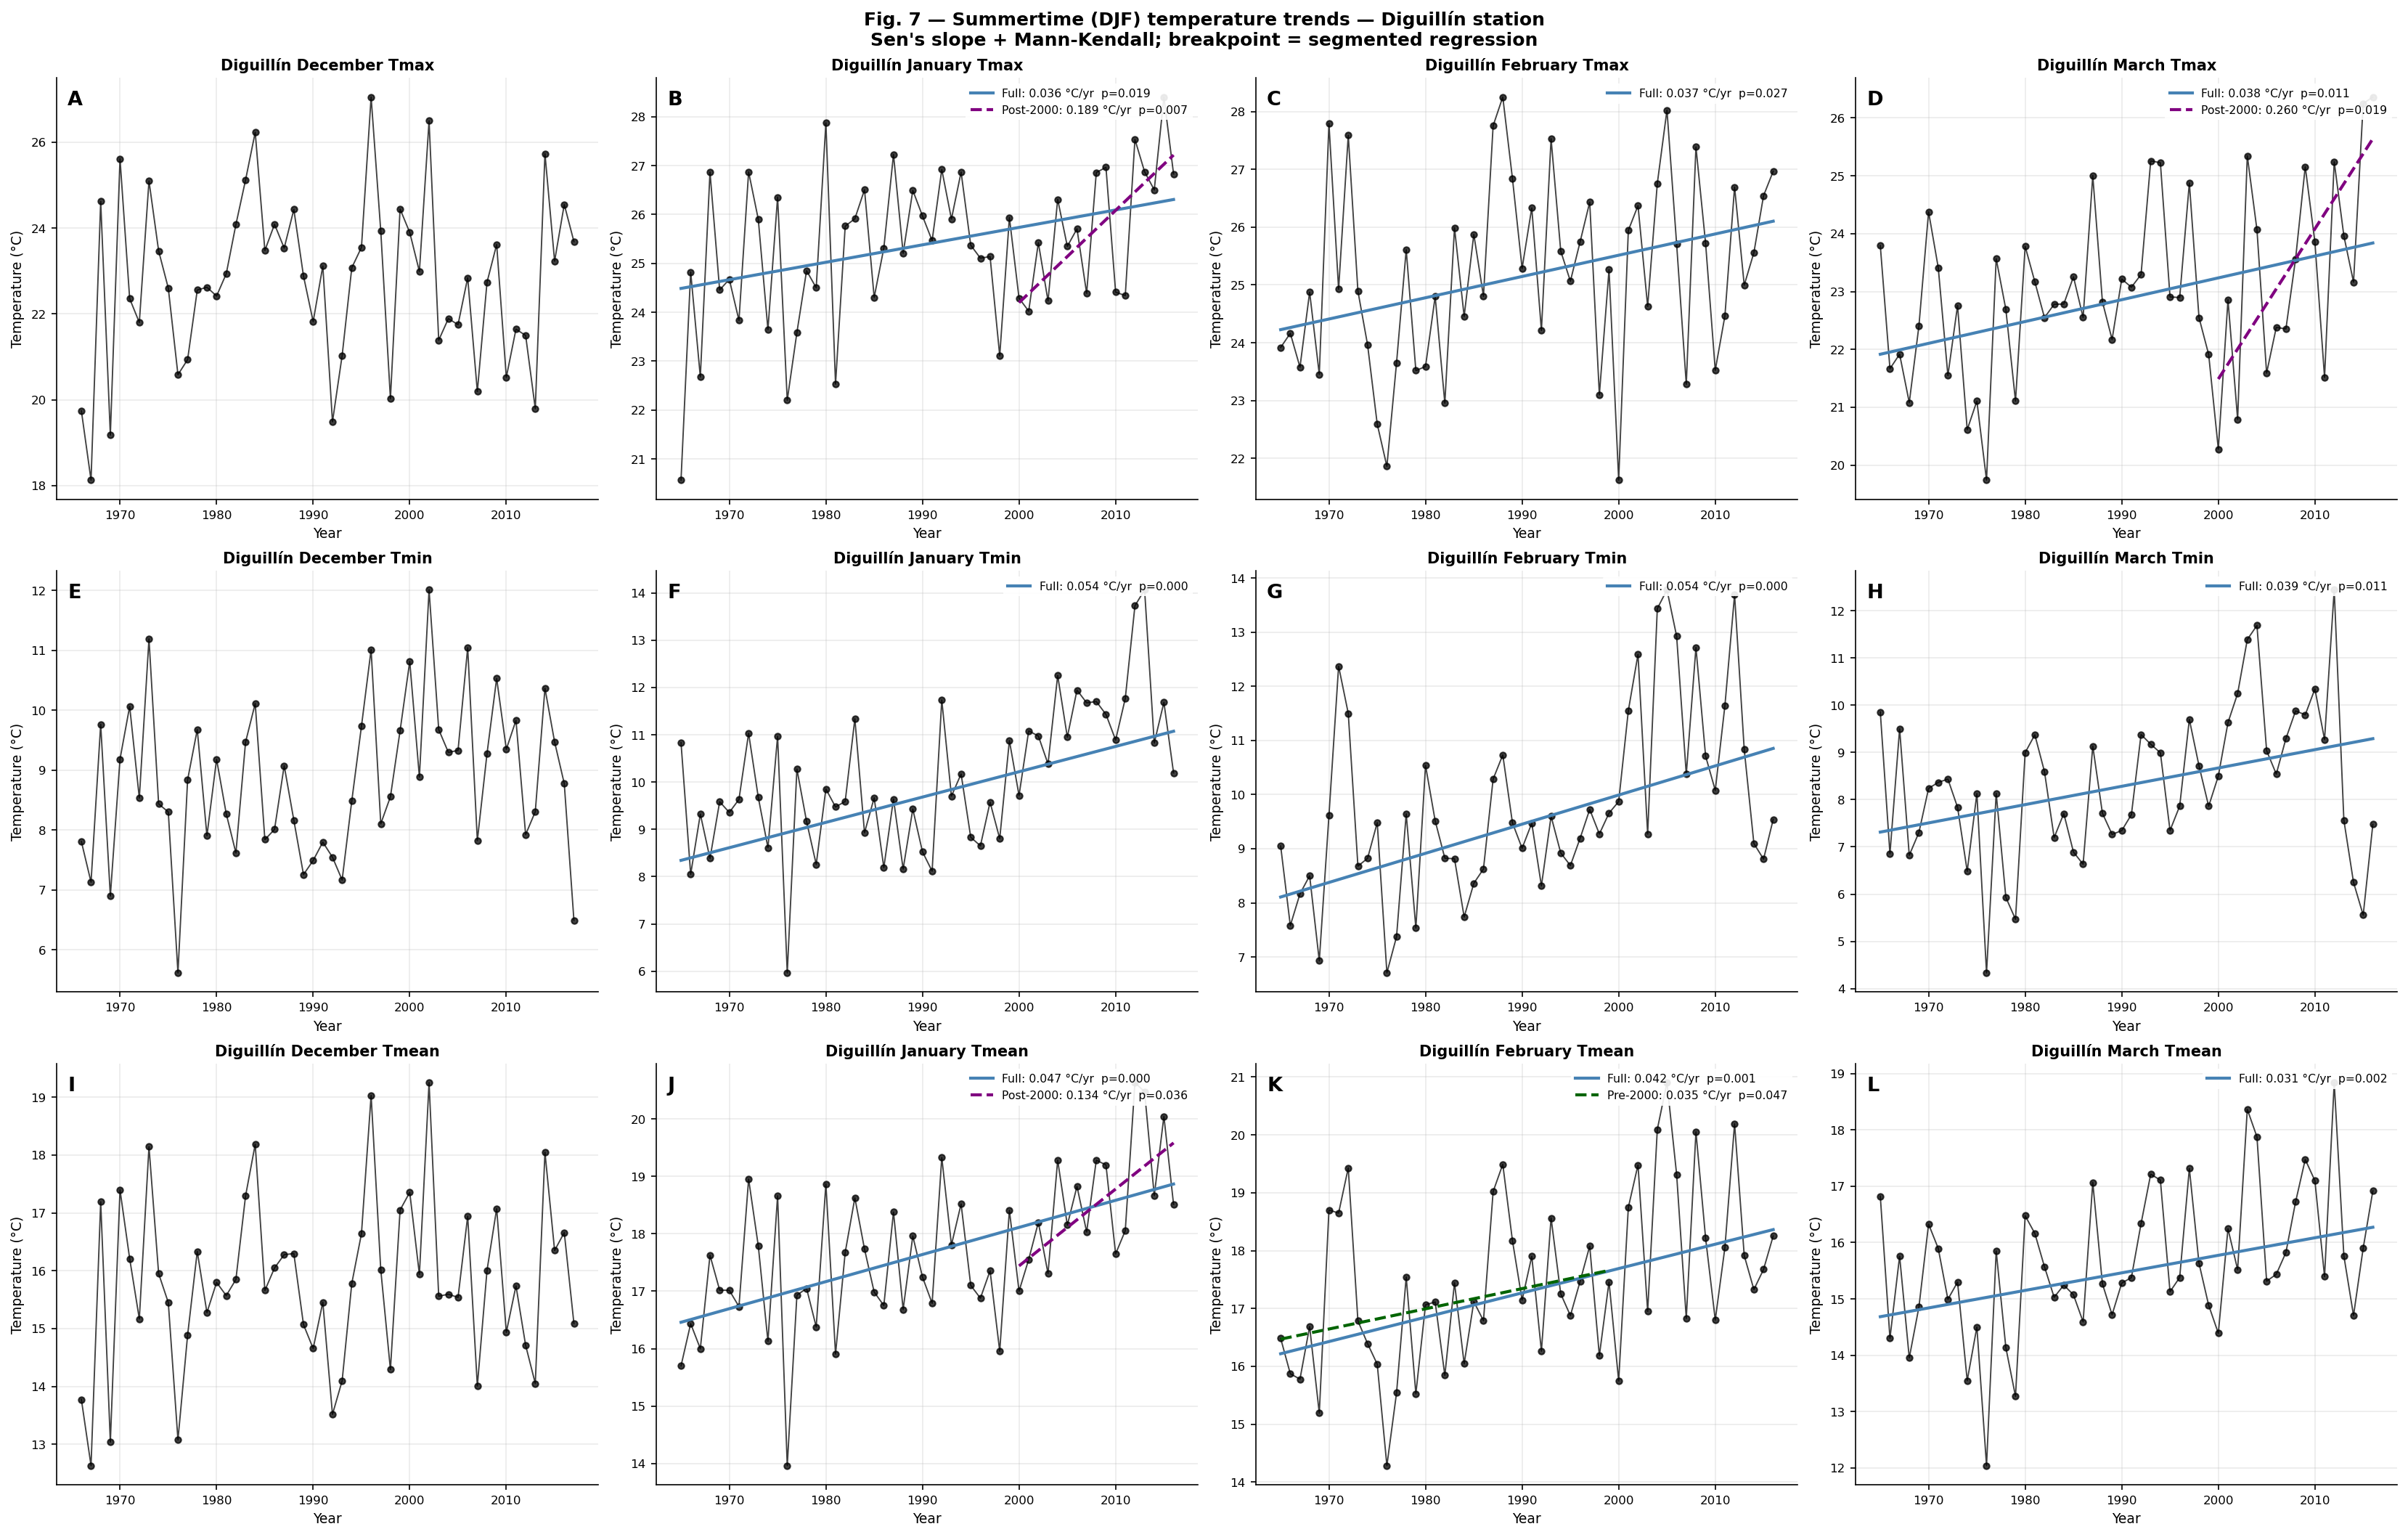

Saved: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures/fig7_summer_temperature.png


In [9]:
print('\nGenerating Fig 7: Summer temperature (DJF)...')

SUMMER_MONTHS = [12, 1, 2, 3]
MONTH_NAMES   = {12: 'December', 1: 'January', 2: 'February', 3: 'March'}
TEMP_VARS       = [
    (tmax_df,  'valor', 'Tmax'),
    (tmin_df,  'valor', 'Tmin'),
    (pd.merge(tmax_df[['date','summer_year','month','valor']].rename(columns={'valor':'tmax'}),
              tmin_df[['date','summer_year','month','valor']].rename(columns={'valor':'tmin'}),
              on=['date','summer_year','month']).assign(
                  valor=lambda d: (d['tmax']+d['tmin'])/2),
     'valor', 'Tmean'),
]

fig7, axes7 = plt.subplots(3, 4, figsize=(22, 14), constrained_layout=True)
panel_idx = 0

for row_idx, (df_t, vcol, var_label) in enumerate(TEMP_VARS):
    for col_idx, month in enumerate(SUMMER_MONTHS):
        ax = axes7[row_idx, col_idx]
        letter = chr(ord('A') + panel_idx)
        series = monthly_agg(df_t, month, vcol, agg='mean')
        series.index = series.index.astype(int)
        plot_panel(ax, series,
                   label=f'Diguillín {MONTH_NAMES[month]} {var_label}',
                   ylabel='Temperature (°C)',
                   unit='°C', panel_letter=letter)
        panel_idx += 1

fig7.suptitle(
    'Fig. 7 — Summertime (DJF) temperature trends — Diguillín station\n'
    'Sen\'s slope + Mann-Kendall; breakpoint = segmented regression',
    fontsize=12, fontweight='bold')

fig7_path = os.path.join(FIGURES_DIR, 'fig7_summer_temperature.png')
fig7.savefig(fig7_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig7_path}')


## Fig 8: Summer (DJF) precipitation — 2×3 grid


Generating Fig 8: Summer precipitation (DJF)...


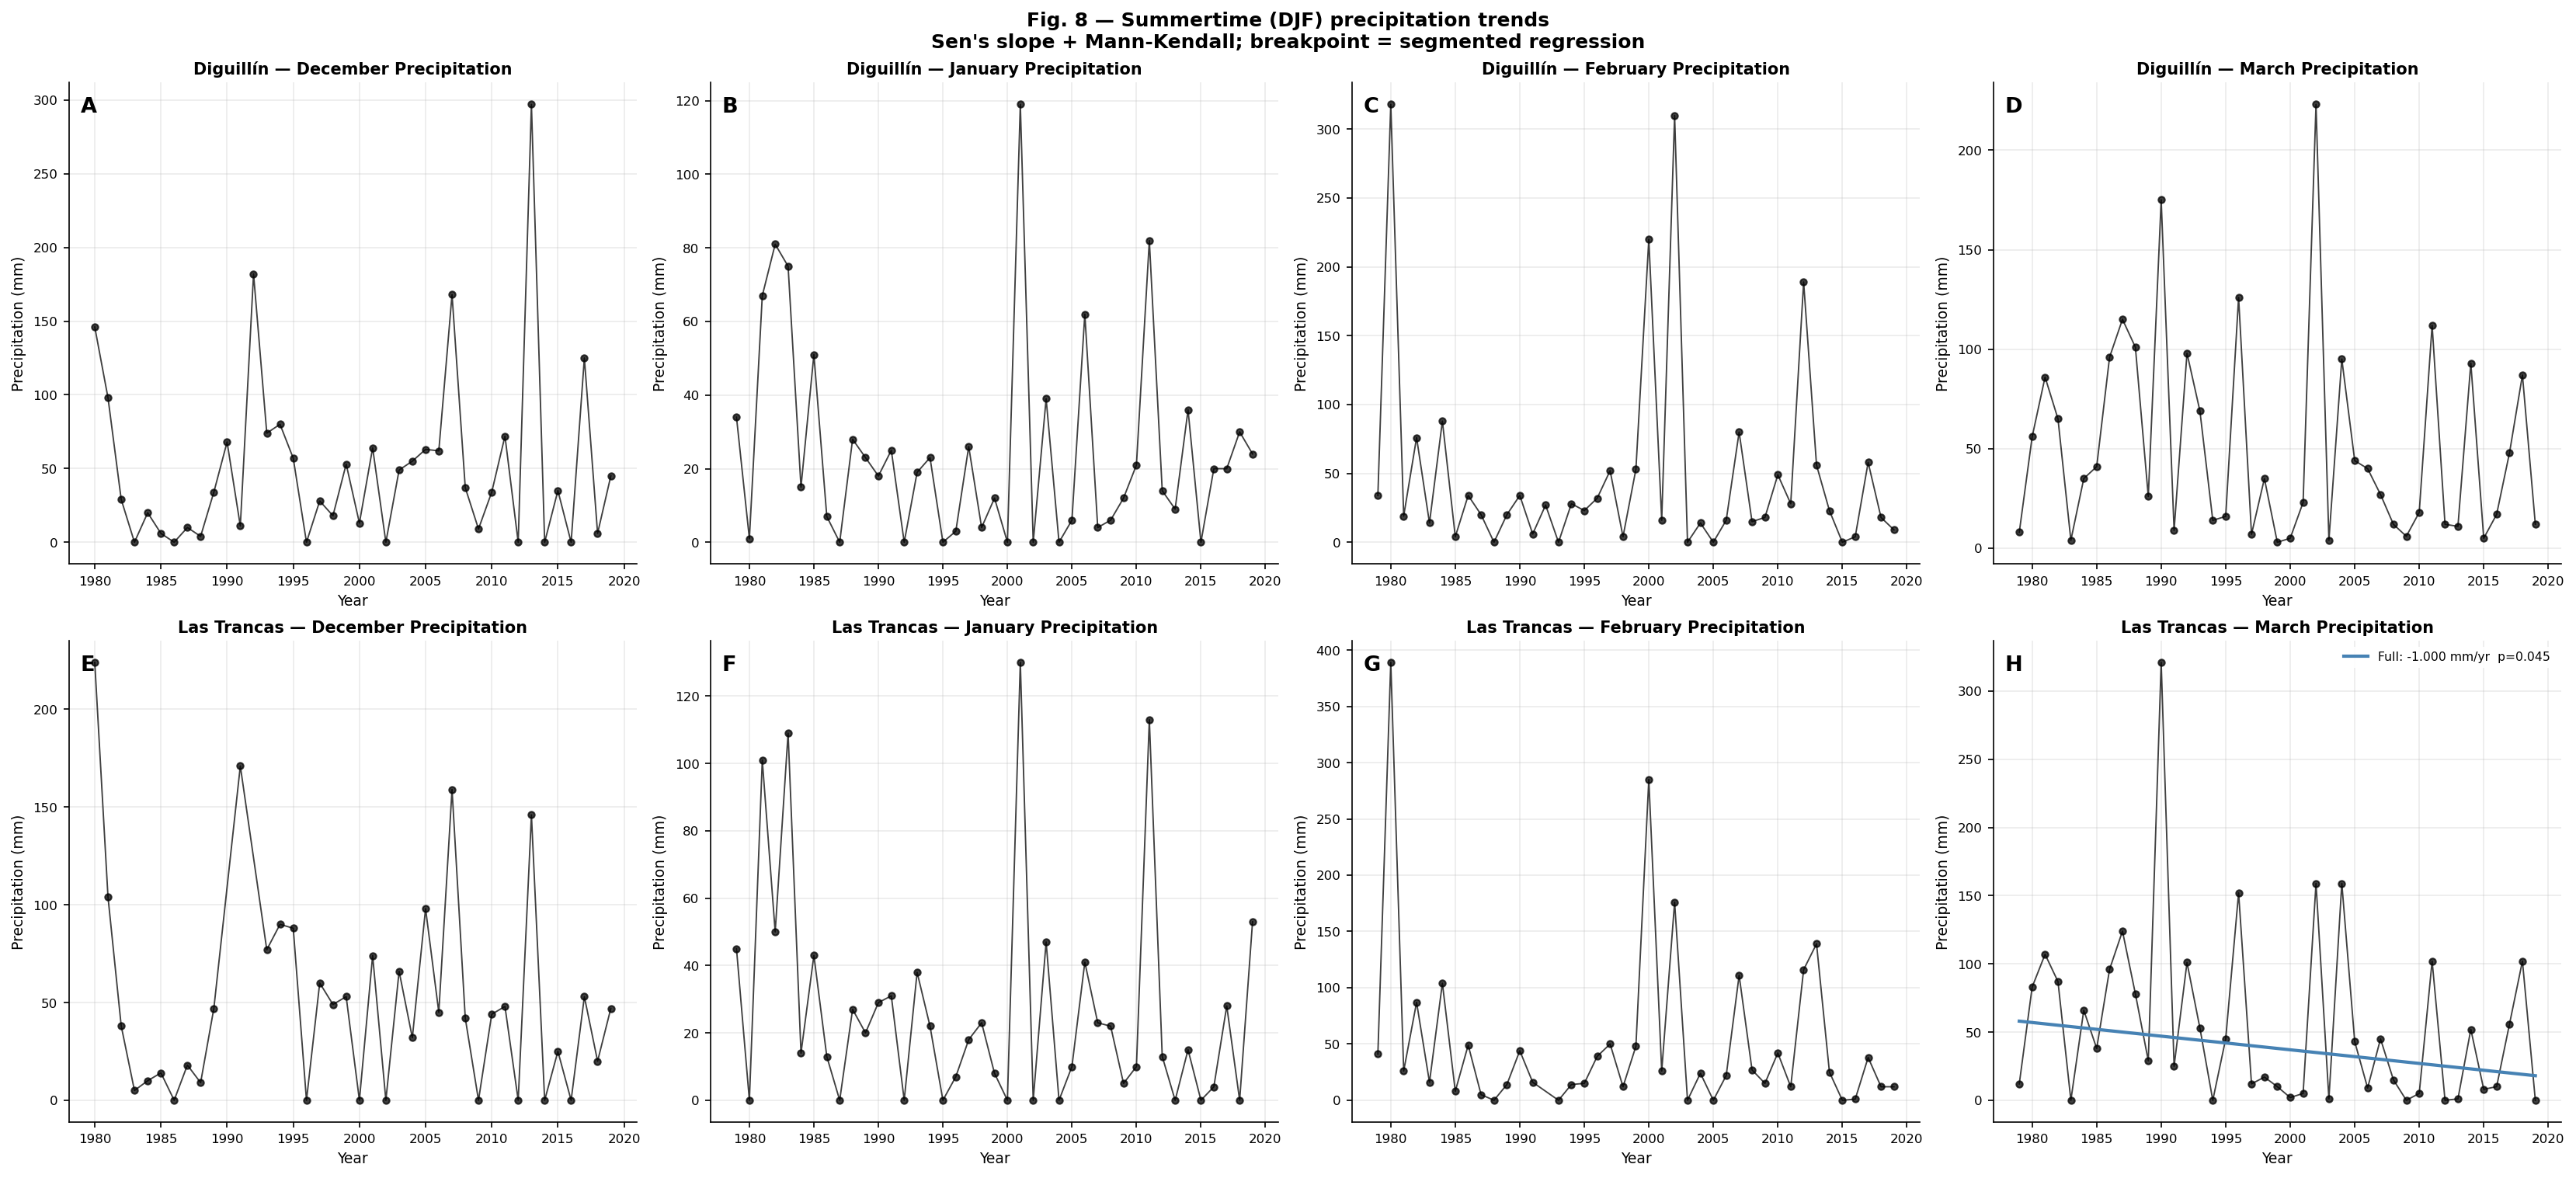

Saved: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures/fig8_summer_precipitation.png


In [10]:
print('\nGenerating Fig 8: Summer precipitation (DJF)...')

fig8, axes8 = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
panel_idx = 0

for row_idx, (station, fpath) in enumerate(PRECIP_FILES.items()):
    df_p = load_precip_monthly(fpath)
    for col_idx, month in enumerate(SUMMER_MONTHS):
        ax     = axes8[row_idx, col_idx]
        letter = chr(ord('A') + panel_idx)
        series = monthly_agg(df_p, month, 'precip', agg='sum')
        series.index = series.index.astype(int)
        plot_panel(ax, series,
                   label=f'{station} — {MONTH_NAMES[month]} Precipitation',
                   ylabel='Precipitation (mm)',
                   unit='mm', panel_letter=letter)
        panel_idx += 1

fig8.suptitle(
    'Fig. 8 — Summertime (DJF) precipitation trends\n'
    'Sen\'s slope + Mann-Kendall; breakpoint = segmented regression',
    fontsize=12, fontweight='bold')

fig8_path = os.path.join(FIGURES_DIR, 'fig8_summer_precipitation.png')
fig8.savefig(fig8_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig8_path}')


## Fig 9: Summer (DJF) streamflow — 1×3 grid


Generating Fig 9: Summer streamflow (DJF)...


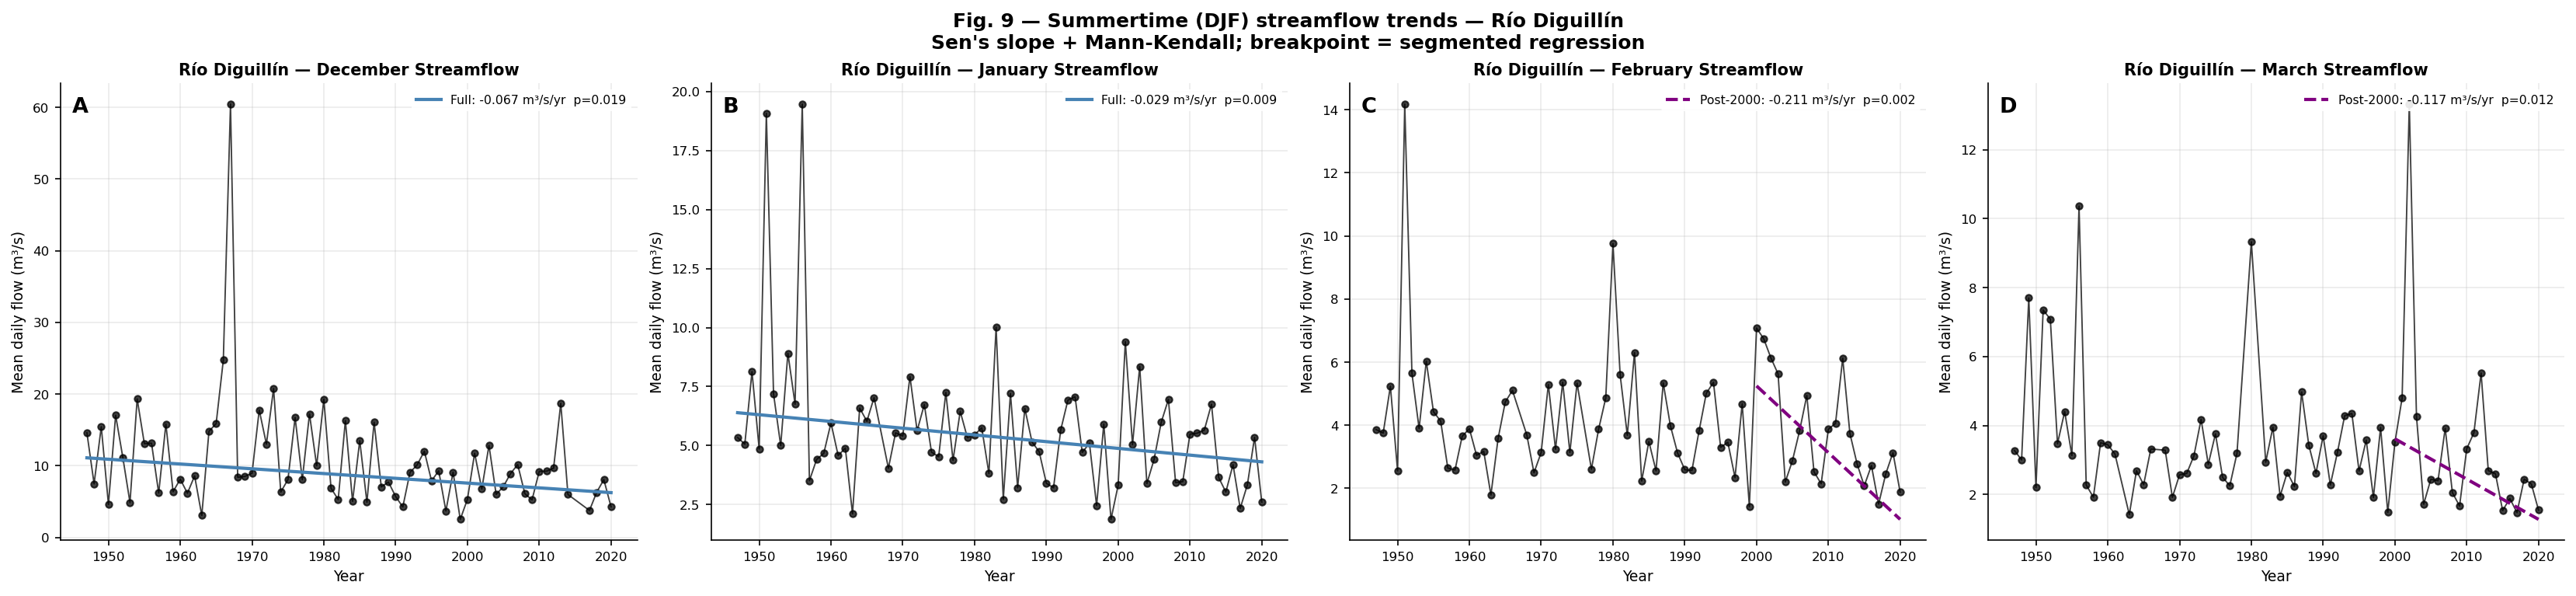

Saved: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures/fig9_summer_streamflow.png


In [11]:
print('\nGenerating Fig 9: Summer streamflow (DJF)...')

fig9, axes9 = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)

for col_idx, month in enumerate(SUMMER_MONTHS):
    ax     = axes9[col_idx]
    letter = chr(ord('A') + col_idx)
    series = monthly_agg(stream_df, month, 'valor', agg='mean')
    series.index = series.index.astype(int)
    plot_panel(ax, series,
               label=f'Río Diguillín — {MONTH_NAMES[month]} Streamflow',
               ylabel='Mean daily flow (m³/s)',
               unit='m³/s', panel_letter=letter)

fig9.suptitle(
    'Fig. 9 — Summertime (DJF) streamflow trends — Río Diguillín\n'
    'Sen\'s slope + Mann-Kendall; breakpoint = segmented regression',
    fontsize=12, fontweight='bold')

fig9_path = os.path.join(FIGURES_DIR, 'fig9_summer_streamflow.png')
fig9.savefig(fig9_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig9_path}')


## Summary statistics table (all trends)

In [12]:
print('\n' + '='*80)
print('HYDROCLIMATIC TREND SUMMARY')
print('Sen\'s slope + Mann-Kendall (full record, pre-2000, post-2000)')
print('Breakpoint from segmented regression with 95% CI')
print('='*80)

def summarise_series(label, series, unit):
    series = series.dropna().sort_index()
    x = series.index.values.astype(float)
    y = series.values.astype(float)

    sl_f, p_f, sig_f = sens_mk(series)
    pre  = series[series.index < 2000]
    post = series[series.index >= 2000]
    sl_pre,  p_pre,  _ = sens_mk(pre)
    sl_post, p_post, _ = sens_mk(post)

    seg = fit_segmented_regression(x, y)
    bp_str = (f'{int(round(seg["breakpoint"]))} '
          f'[{int(seg["bp_ci_lower"])}–{int(seg["bp_ci_upper"])}]'
          if seg else 'no statistically robust breakpoint detected (monotonic trend)')

    print(f'\n{label}')
    print(f'  Full record:  {sl_f:.4f} {unit}/yr  (p={p_f:.4f})'
          f'  {"✓ sig" if sig_f else "ns"}')
    print(f'  Pre-2000:     {sl_pre:.4f} {unit}/yr  (p={p_pre:.4f})'
          f'  {"✓ sig" if p_pre < 0.05 else "ns"}')
    print(f'  Post-2000:    {sl_post:.4f} {unit}/yr  (p={p_post:.4f})'
          f'  {"✓ sig" if p_post < 0.05 else "ns"}')
    print(f'  Breakpoint:   {bp_str}')

# Annual
for station, fpath in PRECIP_FILES.items():
    df_p  = load_precip_monthly(fpath)
    summarise_series(f'Annual precip — {station}', annual_precip(df_p), 'mm')

summarise_series('Annual Tmax  — Diguillín', ann_tmax,   '°C')
summarise_series('Annual Tmin  — Diguillín', ann_tmin,   '°C')
summarise_series('Annual Tmean — Diguillín', ann_tmean,  '°C')
summarise_series('Annual streamflow — Río Diguillín', ann_stream, 'm³/s')

# Summer
print('\n--- SUMMER (DJF) ---')
for station, fpath in PRECIP_FILES.items():
    df_p = load_precip_monthly(fpath)
    for month in SUMMER_MONTHS:
        s = monthly_agg(df_p, month, 'precip', agg='sum')
        s.index = s.index.astype(int)
        summarise_series(f'{MONTH_NAMES[month]} precip — {station}', s, 'mm')

for df_t, vcol, var_lbl in TEMP_VARS:
    for month in SUMMER_MONTHS:
        s = monthly_agg(df_t, month, vcol, agg='mean')
        s.index = s.index.astype(int)
        summarise_series(f'{MONTH_NAMES[month]} {var_lbl} — Diguillín', s, '°C')

for month in SUMMER_MONTHS:
    s = monthly_agg(stream_df, month, 'valor', agg='mean')
    s.index = s.index.astype(int)
    summarise_series(f'{MONTH_NAMES[month]} streamflow — Río Diguillín', s, 'm³/s')

print('\nDone.')



HYDROCLIMATIC TREND SUMMARY
Sen's slope + Mann-Kendall (full record, pre-2000, post-2000)
Breakpoint from segmented regression with 95% CI

Annual precip — Diguillín
  Full record:  -18.9528 mm/yr  (p=0.0224)  ✓ sig
  Pre-2000:     -33.6500 mm/yr  (p=0.2389)  ns
  Post-2000:    -79.2000 mm/yr  (p=0.0013)  ✓ sig
  Breakpoint:   no statistically robust breakpoint detected (monotonic trend)

Annual precip — Las Trancas
  Full record:  -48.8567 mm/yr  (p=0.0000)  ✓ sig
  Pre-2000:     -54.3722 mm/yr  (p=0.0571)  ns
  Post-2000:    -116.7786 mm/yr  (p=0.0003)  ✓ sig
  Breakpoint:   no statistically robust breakpoint detected (monotonic trend)

Annual Tmax  — Diguillín
  Full record:  0.0088 °C/yr  (p=0.2154)  ns
  Pre-2000:     0.0330 °C/yr  (p=0.0097)  ✓ sig
  Post-2000:    0.0860 °C/yr  (p=0.0529)  ns
  Breakpoint:   no statistically robust breakpoint detected (monotonic trend)

Annual Tmin  — Diguillín
  Full record:  0.0290 °C/yr  (p=0.0004)  ✓ sig
  Pre-2000:     0.0229 °C/yr  (p=0.05